# Creating Jupyter notebook widgets with interact/interactive
* (Done) Part 0: Install ipywidgets extension and use "interact" to generate user interface controls that can interact with data
* (Done) Part 1: Generate code for an interval slider
* (Done) Part 2: Dynamically pull the intervals from Derek's code (1% and 99%) into the range slider
* (Done) Part 3: Find where the plotting code updates based on input values and replace with a variable from the slider
* (Done) Part 4: Convert those percentiles to pixels and change the before and after tiles based on user interactions
* (Done) Part 5: Generate a membrane merge preview
* (Done) Part 6: Generate a final preview image with nuclear + membrane
* (Done) Part 7: Populate the for loop of sliding bars into their own respective tabs labeled by channel name

# Set user-defined parameters to tune input to Mesmer
* The first element of "cyclesToUse" and "channelsToUse" is assumed to be the nuclear channel (typically cycle 2, channel 1)
* The remaining elements are assumed to be membrane channels that one intends to merge into a "pan-membrane" channel for Mesmer
* Choose the name of the root directory for all "tiles" data output by Akoya Processor
* Choose the name of the tile within "inTileRootDir" to tune on with "inTile" -- e.g. reg001_X07_Y05


In [1]:
import os
import numpy as np
from skimage import io
from matplotlib import pyplot as plt
from PIL import Image
import pandas as pd
import tifffile
import imageio
import glob
import re
import imagecodecs
# Import interactive widget library
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, fixed, VBox

# Import necessary packages
* Interval Range Slider: https://panel.holoviz.org/reference/widgets/IntRangeSlider.html
* Linking Jupyter Notebook Widget outputs: https://coderzcolumn.com/tutorials/python/interactive-widgets-in-jupyter-notebook-using-ipywidgets
* Building more complex dashboards: https://ipython-books.github.io/33-mastering-widgets-in-the-jupyter-notebook/
* For loop into widget tabs: https://stackoverflow.com/questions/50842160/how-to-display-matplotlib-plots-in-a-jupyter-tab-widget


In [7]:
# User parameters to set

# Paths come from the environment so no sample/accession IDs live in the repo:
#   CODEX_QPTIFF : raw multiplexed image
#   CODEX_DIR    : mcmicro output directory for this sample
#   CODEX_SAMPLE : sample identifier used in the output filename
inFileTiff  = os.environ.get('CODEX_QPTIFF', 'CODEX/raw/scan.qptiff')
outFileTiff = os.path.join(
    os.environ.get('CODEX_DIR', 'CODEX/sample'),
    os.environ.get('CODEX_SAMPLE', 'SAMPLE') + '_nuclear_panmembrane.tif')
channelsToUse = [0, 1, 14, 15] # DAPI, CD19, Vimentin, NAKATPase
#channelsToUse = [0, 14, 15] Only for patient 5

xTileSubset = 1
yTileSubset = 1
xTilePixel = 12530
yTilePixel = 24456
overlap = 0.1

useDefaultSettings = False
quantileDefaultLo = 0.001 # use 0.1 for patient 5 
quantileDefaultHi = 0.999 # use 0.9999 for patient 5

In [6]:
im = tifffile.imread(inFileTiff)
print(im.shape)

(56, 12530, 24456)


In [8]:
if(  im.dtype == 'uint8'):
    maxRange = 255        # Maximum unsigned 8-bit  integer -- i.e. 2**8  - 1
elif(im.dtype == 'uint16'):
    maxRange = 65535      # Maximum unsigned 16-bit integer -- i.e. 2**16 - 1
elif(im.dtype == 'uint32'):
    maxRange = 4294967295 # Maximum unsigned 32-bit integer -- i.e. 2**32 - 1
print(maxRange)

65535


In [9]:
print(im.shape)

(56, 12530, 24456)


# Custom function definitions

In [10]:
# Linearly input data with high and low saturation at "hi" and "lo" respectively
def saturateRescale(x, lo = 0, hi = maxRange, max = maxRange):
    x = np.where(x > hi, hi, x)
    x = np.where(x < lo, lo, x)
    r = hi - lo
    x = x - lo
    x = x / r
    x = x * max
    return np.round(x)

# Read and rescale TIF (read as numpy array "img") using a low/high range that is log2-transformed
def custom_range_image_log2(low_high_range, img):
    # Using across the entire .tif, do linear rescaling with nuclear quantile 0 and 1 which were computed automatically
    img_rescale = saturateRescale(img, 2**low_high_range[0], 2**low_high_range[1])

    fig = plt.figure(figsize=(20,20)) # set up figure configurations
    ax_orig = fig.add_subplot(121) # position for first plot
    ax_rescale = fig.add_subplot(122) #position for second plot

    ax_orig.imshow(img) #plot with original image data
    ax_rescale.imshow(img_rescale) #plot with rescaled image data
    
    ax_orig.set_title('Non Norm')
    ax_rescale.set_title('Norm')

# Add channels together, rescaling to "max" to avoid overflow on 16-bit scale
def addChannels(tif_list, max = maxRange):
    outTiff = np.zeros(tif_list[0].shape)
    for ii in range(len(tif_list)):
        outTiff += tif_list[ii]
    outTiff = saturationFunction(outTiff) # Run this line to minimize the effect of autofluorescent addition
    minMaxQuantile = np.quantile(outTiff, q=(0, 1), axis=(0, 1))
    outTiff = saturateRescale(outTiff, minMaxQuantile[0], minMaxQuantile[1])
    return outTiff
    
# A saturation function that ensures a more grace asymptotic approach to max range. Empirically, minimizes the effect autofluorescent junk when rescaling
def saturationFunction(x):
    #return maxRange / (1 + maxRange / x) # motivated by Michaelis-Menten kinetics
    return maxRange * (1 - np.exp(-x / maxRange)) # motivated by exponential charge flow -- e.g. charging a capacitor
    
def idx2DTo1D(cycle, channel):
    return (cycle - 1) * nChannel + (channel - 1)

# Automatically detect cycle/channel number and read in selected TIFs

In [11]:
xTileCount = np.round((im.shape[2]) / (xTilePixel * (1-overlap)))
yTileCount = np.round((im.shape[1]) / (yTilePixel * (1-overlap)))

xPixel = np.array((xTileSubset-1, xTileSubset)) * round(im.shape[2] / xTileCount) 
yPixel = np.array((yTileSubset-1, yTileSubset)) * round(im.shape[1] / yTileCount) 

print(xPixel)
print(yPixel)

print('Tile X Dimension: {:0.2f}'.format(xTileCount))
print('Tile X Dimension: {:0.2f}'.format(yTileCount))

[    0 12228]
[    0 12530]
Tile X Dimension: 2.00
Tile X Dimension: 1.00



# Load & tune rescaling values for Nuclear and Membrane TIFs
* vFuncSaturateRescale function will calculate the 1%ile and 99%ile for the specified .tif image and plot both the non-normalized original image vs. the rescaled values.
* The tuning bar allows a user to browse and rescale the "Norm" plot to update with new range values
* The cell needs to be rerun or manually reset by dragging the slider to return to the initial rescaling values
* You can also type into the box the range values you want

In [12]:
arr_list = []
xPixel = [8500,8700]
yPixel = [9600,9800]
for ii in range(len(channelsToUse)):
    print(ii)
    arr_list.append(im[channelsToUse[ii],yPixel[0]:yPixel[1],xPixel[0]:xPixel[1]])
    #arr_list.append(im[channelsToUse[ii],:,:])


0
1
2


In [13]:
sub_tab=[widgets.Output() for i in range(len(arr_list))]
tab = widgets.Tab(sub_tab)
tabs_list = ['Nuclear'] + ['Membrane_' + str(ii) for ii in range(1,len(channelsToUse))]

slider_list = []
quantileDefaultLo =0.15
quantileDefaultHi = 1
for ii in range(len(arr_list)): #get range from list that holds membrane data
    tab.set_title(ii, tabs_list[ii])
    #print(ii)

    with sub_tab[ii]:
        quantile_default = np.log2(np.quantile(arr_list[ii], q = (quantileDefaultLo, quantileDefaultHi), axis=(0,1))) #calculate quantiles for each channel
        slider_list.append(widgets.FloatRangeSlider(
            value=[quantile_default[0], quantile_default[1]],
            min=0, 
            max=np.log2(maxRange+1), 
            step=0.1,
            readout_format='.1f',
            description='Log2 Mk ' + str(ii+1) + ':',
            disabled=False,
            continuous_update=True,
            orientation='horizontal',
            readout=True
        ))
        interact(custom_range_image_log2, low_high_range = slider_list[ii], img = fixed(arr_list[ii]))
display(tab)

In [44]:
arr_list = []
xPixel = [8500,8700]
yPixel = [9600,9800]
for ii in range(len(channelsToUse)):
    arr_list.append(im[channelsToUse[ii],yPixel[0]:yPixel[1],xPixel[0]:xPixel[1]])
    #arr_list.append(im[channelsToUse[ii],:,:])


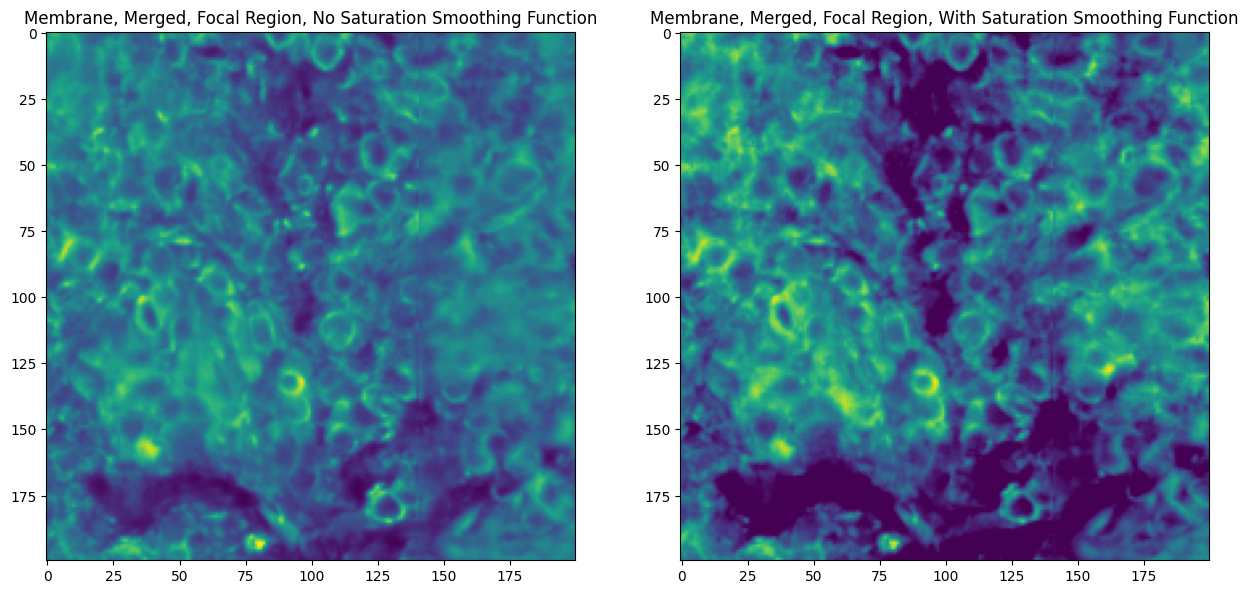

In [45]:
# Run this code block for quick view of merged membrane channels


lo_quantile_list = [int(np.round(2**(slider_list[ii].value[0]))) for ii in range(len(slider_list))]
hi_quantile_list = [int(np.round(2**(slider_list[ii].value[1]))) for ii in range(len(slider_list))]
membrane_channels = arr_list[1:]
membrane_lo_quantile_list = lo_quantile_list[1:]
membrane_hi_quantile_list = hi_quantile_list[1:]
orig_tif_list = []
norm_tif_list = []

for ii, arr in enumerate(membrane_channels):
    orig_tif_list.append(arr)
    norm_tif_list.append(
        saturateRescale(
            x=orig_tif_list[ii],          
            lo=membrane_lo_quantile_list[ii], 
            hi=membrane_hi_quantile_list[ii]
        )
    )

im1 = addChannels(orig_tif_list) 
im2 = addChannels(norm_tif_list)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(im1)
ax[1].imshow(im2)
ax[0].set_title('Membrane, Merged, Focal Region, No Saturation Smoothing Function')
ax[1].set_title('Membrane, Merged, Focal Region, With Saturation Smoothing Function')
plt.show()


# Obtain low/high tuning parameters from slider bars above or by default settings

In [46]:
if useDefaultSettings == False:
    lo_quantile_list = [int(np.round(2**(slider_list[ii].value[0]))) for ii in range(len(slider_list))]
    hi_quantile_list = [int(np.round(2**(slider_list[ii].value[1]))) for ii in range(len(slider_list))]

if useDefaultSettings == True:   
    lo_quantile_list = np.round([np.quantile(im[ii,:,:], q = quantileDefaultLo, axis=(0,1)) for ii in channelsToUse])
    hi_quantile_list = np.round([np.quantile(im[ii,:,:], q = quantileDefaultHi, axis=(0,1)) for ii in channelsToUse])

print(lo_quantile_list)
print(hi_quantile_list)

[1, 9410, 3104]
[65536, 65536, 65536]


# Rescale nuclear data and plot result

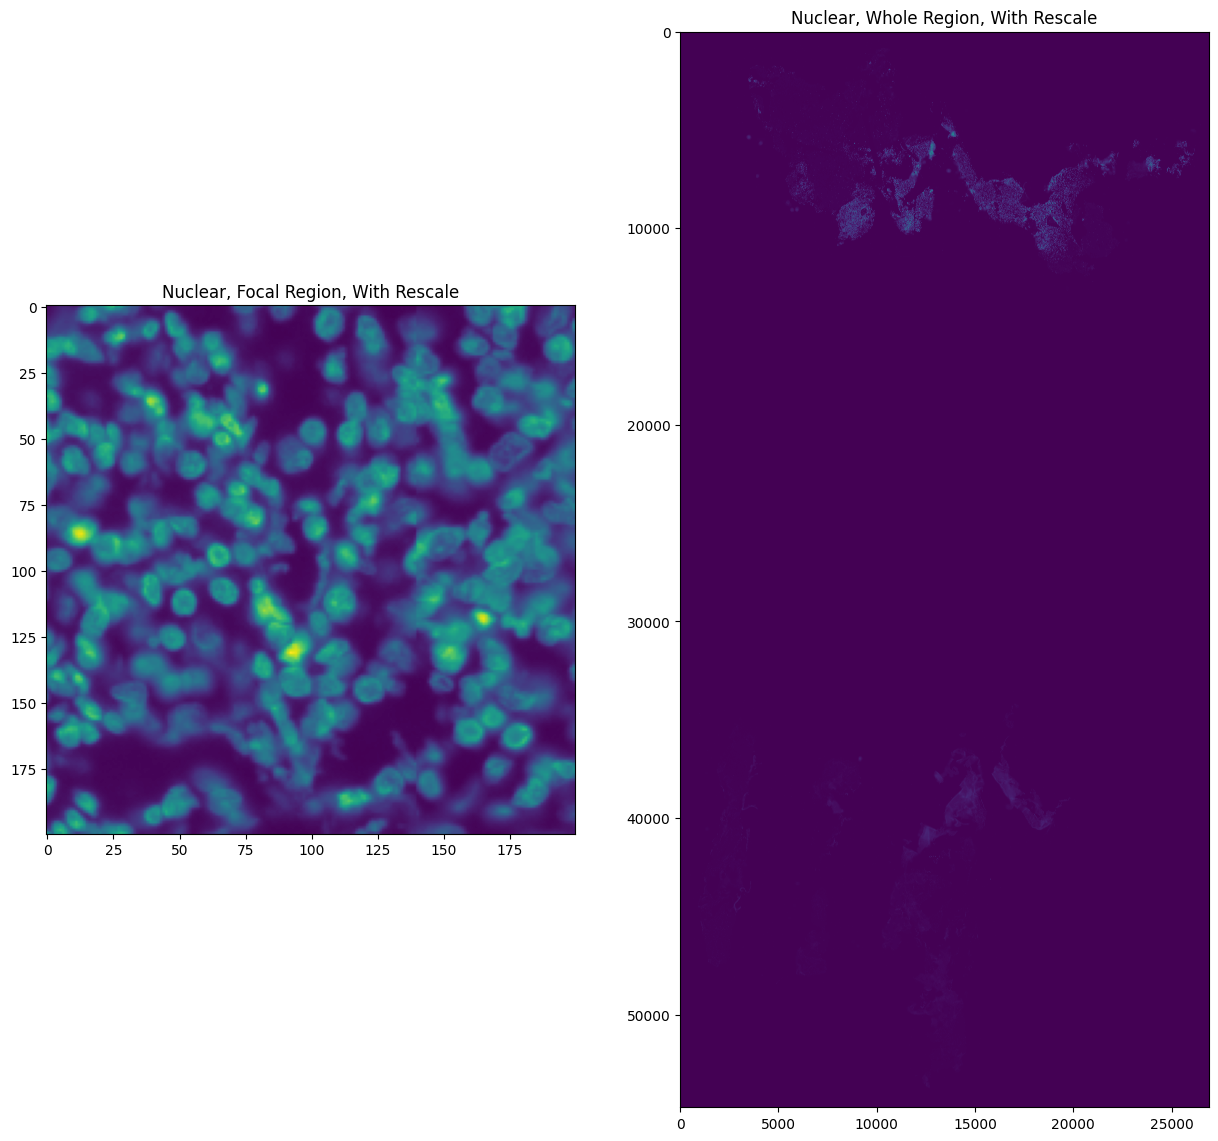

In [47]:
nuclearIdx = 0
nuclear_rescale = saturateRescale(x = arr_list[nuclearIdx], lo = lo_quantile_list[nuclearIdx], hi = hi_quantile_list[nuclearIdx])
nuclear_rescale_all = saturateRescale(x = im[channelsToUse[nuclearIdx],], lo = lo_quantile_list[nuclearIdx], hi = hi_quantile_list[nuclearIdx])

# Plot nuclear data with and without rescaling
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(nuclear_rescale)
ax[1].imshow(nuclear_rescale_all)

ax[0].set_title('Nuclear, Focal Region, With Rescale')
ax[1].set_title('Nuclear, Whole Region, With Rescale')

plt.show()

In [48]:
membrane_channels = arr_list[1:]
membrane_lo_quantile_list = lo_quantile_list[1:]
membrane_hi_quantile_list = hi_quantile_list[1:]

orig_tif_list = []
norm_tif_list = []
norm_tif_list_all = []

for ii, arr in enumerate(membrane_channels):
    orig_tif_list.append(arr)
    norm_tif_list.append(    saturateRescale(x=orig_tif_list[ii],          lo=membrane_lo_quantile_list[ii], hi=membrane_hi_quantile_list[ii]))
    norm_tif_list_all.append(saturateRescale(x=im[channelsToUse[ii+1],], lo=membrane_lo_quantile_list[ii], hi=membrane_hi_quantile_list[ii]))


# Rescale and merge all membrane data and plot result

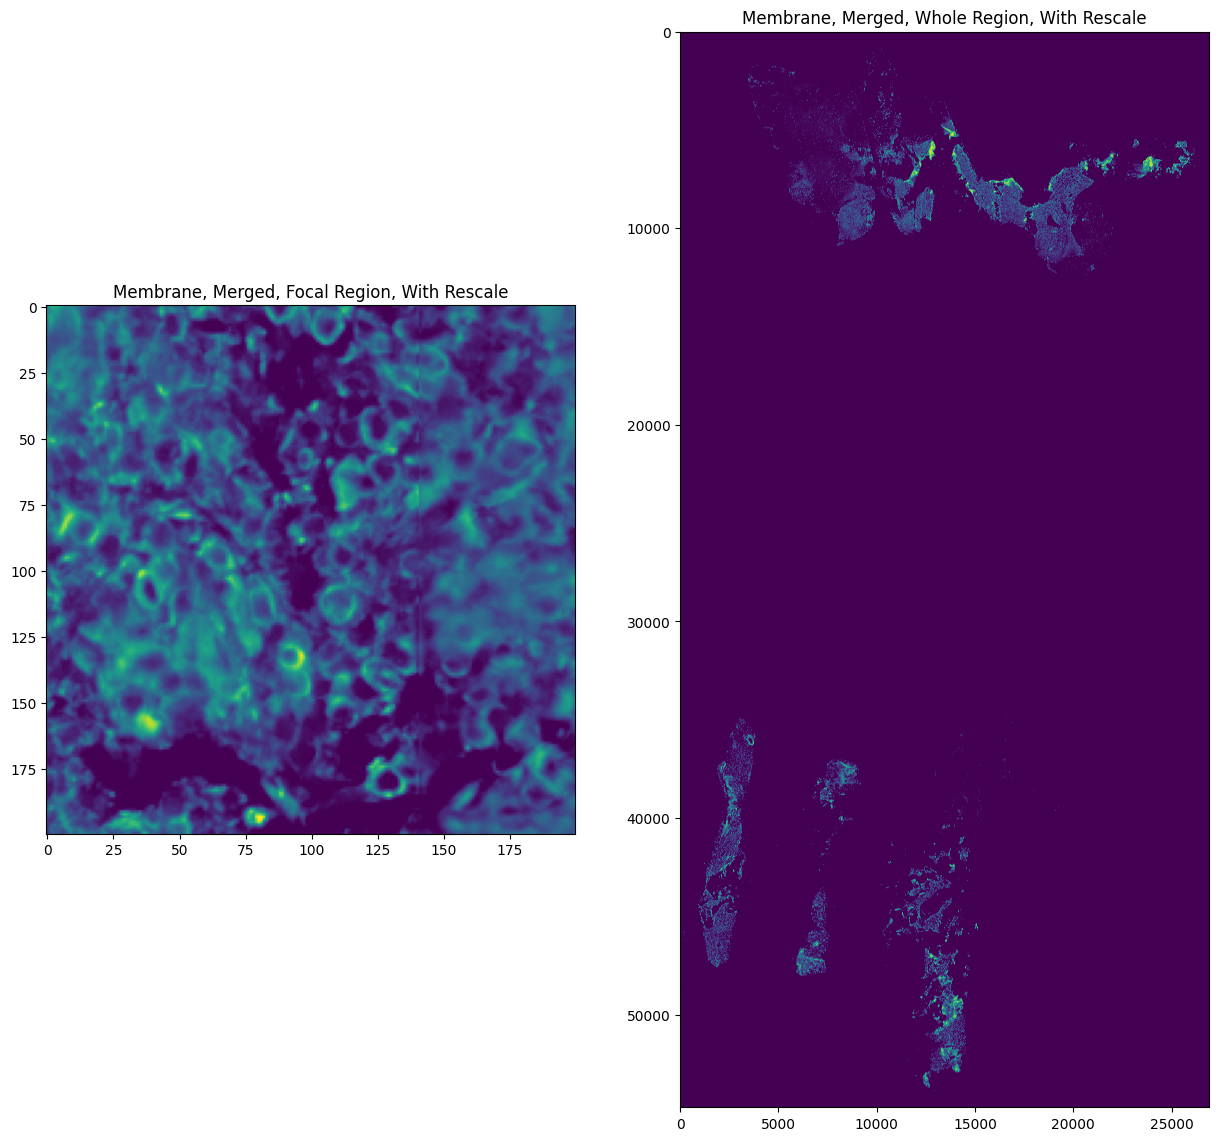

In [49]:
membrane_orig_merged     = addChannels(orig_tif_list)
membrane_norm_merged     = addChannels(norm_tif_list)
membrane_norm_all_merged = addChannels(norm_tif_list_all)

# Plot merged data with and without rescaling
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(membrane_norm_merged)
ax[1].imshow(membrane_norm_all_merged)

ax[0].set_title('Membrane, Merged, Focal Region, With Rescale')
ax[1].set_title('Membrane, Merged, Whole Region, With Rescale')

plt.show()

# Compile nuclear and pan-membrane channel into a TIF stack

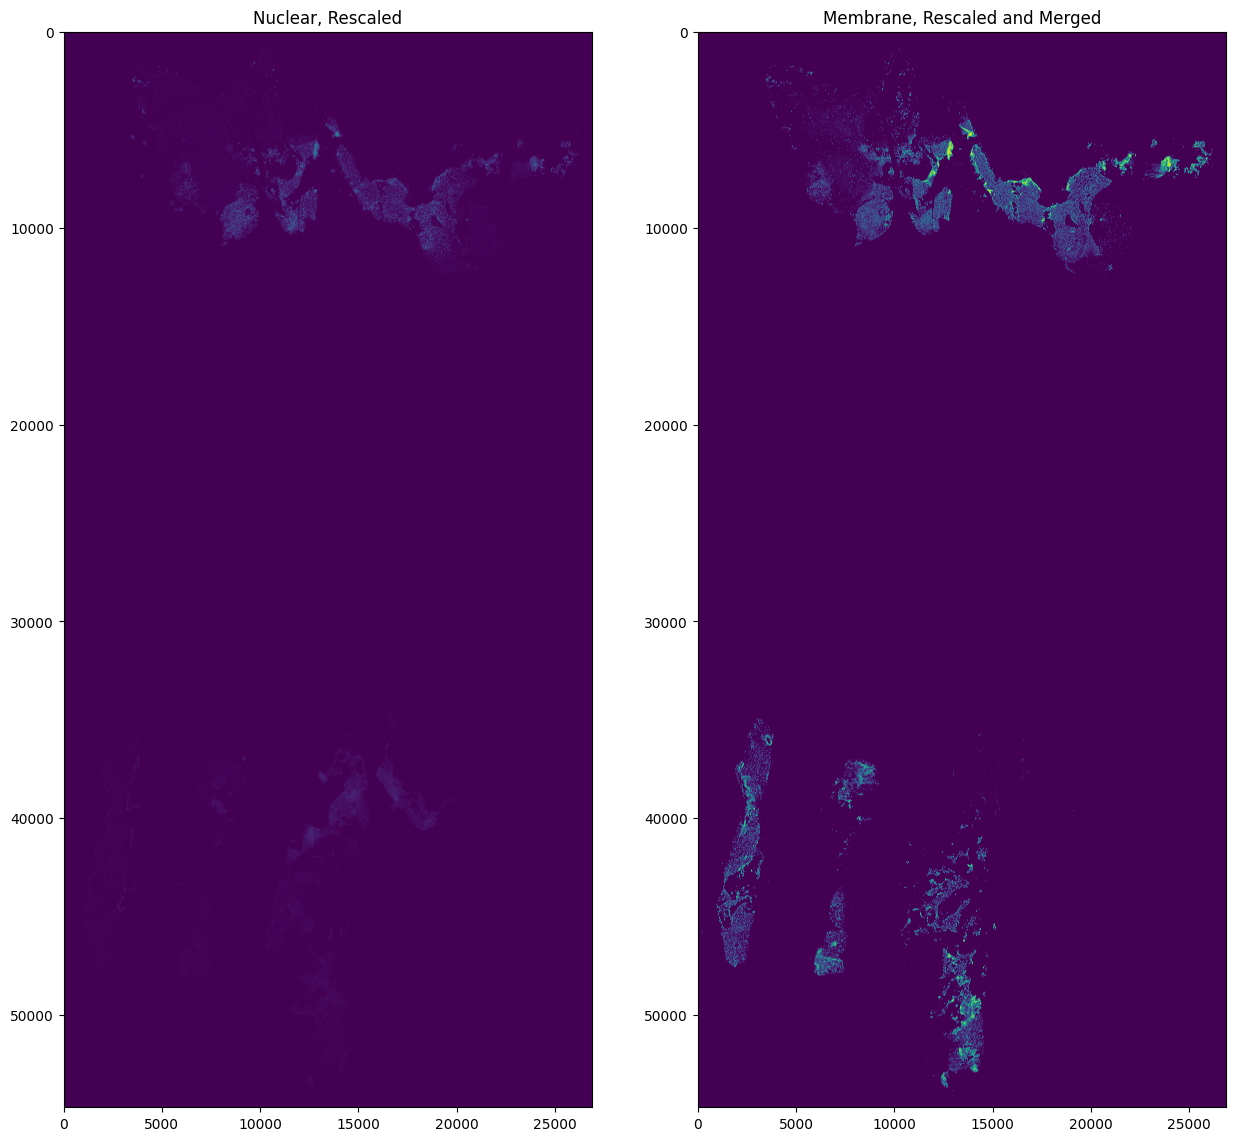

In [50]:
# Put nuclear and pan-membrane channels into a stack along axis=2
tif_for_mesmer = np.stack((nuclear_rescale_all, membrane_norm_all_merged), axis=2)

# Plot nuclear and pan-membrane stack
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(tif_for_mesmer[:,:,0])
ax[1].imshow(tif_for_mesmer[:,:,1])

ax[0].set_title('Nuclear, Rescaled')
ax[1].set_title('Membrane, Rescaled and Merged')

plt.show()

###### Save resulting OME.TIFF as input to Mesmer/DeepCell

In [ ]:
# Write nuclear and pan-membrane stack output as OME.TIF in the current directory
tifffile.imwrite(outFileTiff, np.transpose(tif_for_mesmer, (2,0,1)).astype('uint16'))